In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
import geopandas as gpd

print(gpd.__version__)

1.1.3


In [6]:
import requests

url = "https://raw.githubusercontent.com/wmgeolab/geoBoundaries/main/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1.geojson"

response = requests.get(url)

print(response.status_code)
print(response.headers.get("content-type"))

200
text/plain; charset=utf-8


In [7]:
import requests

url = "https://raw.githubusercontent.com/wmgeolab/geoBoundaries/main/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1.geojson"

response = requests.get(url)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("content-type"))
print("File size:", len(response.content), "bytes")

Status code: 200
Content type: text/plain; charset=utf-8
File size: 132 bytes


In [8]:
print(response.text)

version https://git-lfs.github.com/spec/v1
oid sha256:64fa218ac3d453cc1e66412ff461c5dfa1a4a1ade0da93b239a9891b587d28f9
size 2289696



In [9]:
import requests

url = "https://raw.githubusercontent.com/samayo/geojson-nigeria/master/nigeria-states.json"

response = requests.get(url)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")
print(response.text[:100])

Status code: 404
File size: 14 bytes
404: Not Found


In [10]:
import requests

url = "https://www.geoboundaries.org/api/current/gbOpen/NGA/ADM1/"

response = requests.get(url)

print("Status code:", response.status_code)
print(response.text[:1000])

Status code: 200
{"boundaryID": "NGA-ADM1-27671186", "boundaryName": "Nigeria", "boundaryISO": "NGA", "boundaryYearRepresented": "2022", "boundaryType": "ADM1", "boundaryCanonical": "State", "boundarySource": "GRID3", "boundaryLicense": "Creative Commons Attribution 4.0 International (CC BY 4.0)", "licenseDetail": "nan", "licenseSource": "data.grid3.org/datasets/grid3-nigeria-state-boundaries/explore?location=8.992006%2C8.685290%2C6.82", "boundarySourceURL": "data.grid3.org/datasets/grid3-nigeria-state-boundaries/explore?location=8.992006%2C8.685290%2C6.82", "sourceDataUpdateDate": "Sun Feb 26 12:26:14 2023", "buildDate": "Dec 12, 2023", "Continent": "Africa", "UNSDG-region": "Sub-Saharan Africa", "UNSDG-subregion": "Western Africa", "worldBankIncomeGroup": "Lower-middle-income Countries", "admUnitCount": "37", "meanVertices": "1453.0", "minVertices": "125", "maxVertices": "6716", "meanPerimeterLengthKM": "981.5494278783524", "minPerimeterLengthKM": "311.0605998737737", "maxPerimeterLe

In [11]:
data = response.json()

print(data.keys())

dict_keys(['boundaryID', 'boundaryName', 'boundaryISO', 'boundaryYearRepresented', 'boundaryType', 'boundaryCanonical', 'boundarySource', 'boundaryLicense', 'licenseDetail', 'licenseSource', 'boundarySourceURL', 'sourceDataUpdateDate', 'buildDate', 'Continent', 'UNSDG-region', 'UNSDG-subregion', 'worldBankIncomeGroup', 'admUnitCount', 'meanVertices', 'minVertices', 'maxVertices', 'meanPerimeterLengthKM', 'minPerimeterLengthKM', 'maxPerimeterLengthKM', 'meanAreaSqKM', 'minAreaSqKM', 'maxAreaSqKM', 'staticDownloadLink', 'gjDownloadURL', 'tjDownloadURL', 'imagePreview', 'simplifiedGeometryGeoJSON'])


In [12]:
for key, value in data.items():
    if "url" in key.lower() or "download" in key.lower():
        print(key, ":", value)

boundarySourceURL : data.grid3.org/datasets/grid3-nigeria-state-boundaries/explore?location=8.992006%2C8.685290%2C6.82
staticDownloadLink : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1-all.zip
gjDownloadURL : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1.geojson
tjDownloadURL : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM1/geoBoundaries-NGA-ADM1.topojson


In [13]:
import requests

url = data["gjDownloadURL"]

response = requests.get(url)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

Status code: 200
File size: 2289696 bytes


In [14]:
with open("nigeria_states.geojson", "wb") as f:
    f.write(response.content)

print("Nigeria state boundary file saved successfully.")

Nigeria state boundary file saved successfully.


In [15]:
nigeria = gpd.read_file("nigeria_states.geojson")

print("Number of administrative units:", len(nigeria))
print(nigeria.head())

Number of administrative units: 37
                         shapeName shapeISO                  shapeID  \
0                      Cross River    NG-CR  27671186B81745654473385   
1  Abuja Federal Capital Territory    NG-FC  27671186B76269877687363   
2                             Ogun    NG-OG  27671186B83907961412659   
3                              Oyo    NG-OY  27671186B56513237316251   
4                           Sokoto    NG-SO  27671186B99510750195830   

  shapeGroup shapeType                                           geometry  
0        NGA      ADM1  POLYGON ((8.2743 4.85474, 8.29153 4.84805, 8.3...  
1        NGA      ADM1  POLYGON ((6.98081 8.44373, 6.98562 8.44342, 7....  
2        NGA      ADM1  POLYGON ((4.48324 6.32605, 4.48837 6.33622, 4....  
3        NGA      ADM1  POLYGON ((4.08836 7.13345, 4.08764 7.13805, 4....  
4        NGA      ADM1  POLYGON ((4.1264 13.24967, 4.17857 13.25407, 4...  


In [16]:
kogi = nigeria[nigeria["shapeName"] == "Kogi"].copy()

kogi

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
13,Kogi,NG-KO,27671186B96047513549152,NGA,ADM1,"POLYGON ((6.82789 8.45755, 6.82784 8.45716, 6...."


In [17]:
print("Number of Kogi features:", len(kogi))

Number of Kogi features: 1


In [18]:
url_adm2 = "https://www.geoboundaries.org/api/current/gbOpen/NGA/ADM2/"

response_adm2 = requests.get(url_adm2)

print("Status code:", response_adm2.status_code)
print(response_adm2.text[:500])

Status code: 200
{"boundaryID": "NGA-ADM2-59680162", "boundaryName": "Nigeria", "boundaryISO": "NGA", "boundaryYearRepresented": "2022", "boundaryType": "ADM2", "boundaryCanonical": "Local Government Areas", "boundarySource": "GRID3", "boundaryLicense": "Creative Commons Attribution 4.0 International (CC BY 4.0)", "licenseDetail": "nan", "licenseSource": "data.grid3.org/datasets/grid3-nigeria-local-government-area-boundaries-1/explore?location=8.959048%2C8.685290%2C6.61", "boundarySourceURL": "data.grid3.org/dat


In [19]:
data_adm2 = response_adm2.json()

for key, value in data_adm2.items():
    if "url" in key.lower() or "download" in key.lower():
        print(key, ":", value)

boundarySourceURL : data.grid3.org/datasets/grid3-nigeria-local-government-area-boundaries-1/explore?location=8.959048%2C8.685290%2C6.61
staticDownloadLink : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM2/geoBoundaries-NGA-ADM2-all.zip
gjDownloadURL : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM2/geoBoundaries-NGA-ADM2.geojson
tjDownloadURL : https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/NGA/ADM2/geoBoundaries-NGA-ADM2.topojson


In [20]:
url_adm2 = data_adm2["gjDownloadURL"]

response_adm2_file = requests.get(url_adm2)

print("Status code:", response_adm2_file.status_code)
print("File size:", len(response_adm2_file.content), "bytes")

Status code: 200
File size: 9422551 bytes


In [21]:
with open("nigeria_lgas.geojson", "wb") as f:
    f.write(response_adm2_file.content)

print("Nigeria LGA boundary file saved successfully.")

Nigeria LGA boundary file saved successfully.


In [22]:
lgas = gpd.read_file("nigeria_lgas.geojson")

print("Number of LGA features:", len(lgas))

Number of LGA features: 774


In [23]:
lgas.head()

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Eastern Obolo,,59680162B7891718144591,NGA,ADM2,"POLYGON ((7.56201 4.51388, 7.57134 4.51233, 7...."
1,Ekeremor,,59680162B22876202690460,NGA,ADM2,"POLYGON ((5.99261 4.89302, 5.98824 4.90425, 5...."
2,Degema,,59680162B23543460253472,NGA,ADM2,"POLYGON ((6.85818 4.39824, 6.95485 4.37353, 6...."
3,Andoni,,59680162B90577513466378,NGA,ADM2,"POLYGON ((7.3246 4.43947, 7.33342 4.44372, 7.3..."
4,Akpabuyo,,59680162B58958286313368,NGA,ADM2,"POLYGON ((8.39659 4.78065, 8.40093 4.78882, 8...."


In [24]:
print(lgas.columns.tolist())

['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


In [25]:
print(lgas[["shapeName"]].drop_duplicates().sort_values("shapeName").to_string(index=False))

             shapeName
             Aba North
             Aba South
                Abadam
                 Abaji
                  Abak
             Abakaliki
        Abeokuta North
        Abeokuta South
                   Abi
           Aboh-Mbaise
            Abua/Odual
                 Adavi
                   Ado
           Ado Odo/Ota
             Ado-Ekiti
                Afijio
          Afikpo North
          Afikpo South
                 Agaie
                 Agatu
                 Agege
                Aguata
                Agwara
         Ahiazu-Mbaise
           Ahoada East
           Ahoada West
              Ajaokuta
      Ajeromi/Ifelodun
                Ajingi
               Akamkpa
              Akinyele
                  Akko
      Akoko North East
      Akoko North West
      Akoko South East
      Akoko South West
             Akoko-Edo
              Akpabuyo
            Akuku Toru
           Akure North
           Akure South
               Akwanga
           

In [26]:
dekina = lgas[lgas["shapeName"] == "Dekina"].copy()

print("Number of Dekina features:", len(dekina))

Number of Dekina features: 1


In [27]:
dekina

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
713,Dekina,,59680162B92999716235821,NGA,ADM2,"POLYGON ((7.34913 7.84698, 7.34673 7.84171, 7...."


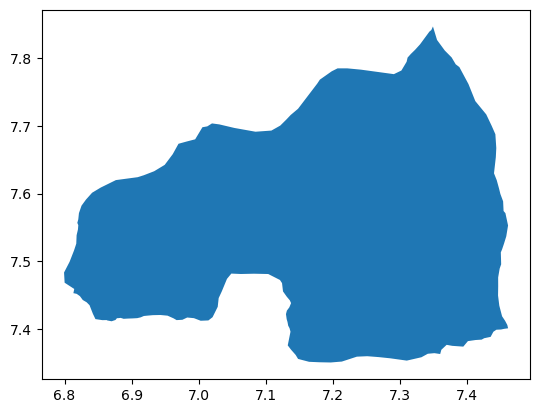

In [28]:
dekina.plot()
plt.show()

In [29]:
print(dekina.columns.tolist())

['shapeName', 'shapeISO', 'shapeID', 'shapeGroup', 'shapeType', 'geometry']


In [30]:
print(dekina[["shapeName", "shapeID", "shapeGroup"]])

    shapeName                  shapeID shapeGroup
713    Dekina  59680162B92999716235821        NGA


In [31]:
abocho_lat = 7.572112129533082
abocho_lon = 6.990155135780286

In [32]:
from shapely.geometry import Point

abocho = Point(6.990155135780286, 7.572112129533082)
emewe_odu = Point(7.038967950064748, 7.690877825672211)

In [33]:
locations = gpd.GeoDataFrame(
    {
        "Location": ["Abocho", "Emewe-Odu"]
    },
    geometry=[abocho, emewe_odu],
    crs="EPSG:4326"
)

locations

,Location,geometry
0,Abocho,POINT (6.99016 7.57211)
1,Emewe-Odu,POINT (7.03897 7.69088)


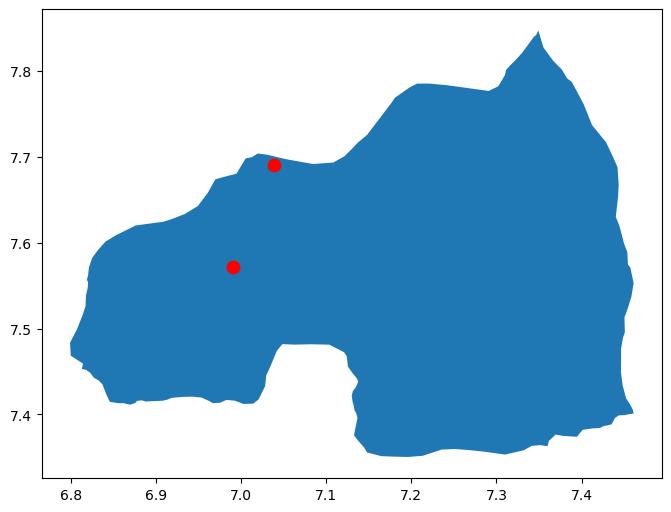

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))

dekina.plot(ax=ax)

locations.plot(
    ax=ax,
    markersize=80,
    color="red"
)

plt.show()

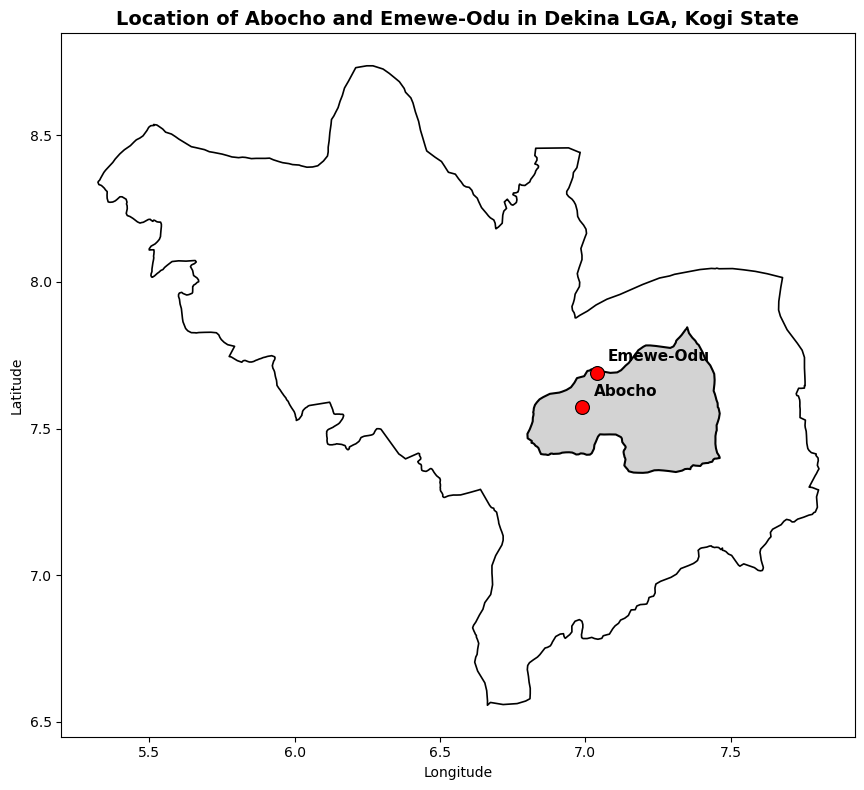

In [35]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Kogi State
kogi.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black",
    linewidth=1.2
)

# Plot Dekina LGA
dekina.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Plot study locations
locations.plot(
    ax=ax,
    color="red",
    markersize=100,
    edgecolor="black",
    linewidth=0.8
)

# Add location labels
for x, y, label in zip(
    locations.geometry.x,
    locations.geometry.y,
    locations["Location"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

# Title
ax.set_title(
    "Location of Abocho and Emewe-Odu in Dekina LGA, Kogi State",
    fontsize=14,
    fontweight="bold"
)

# Axis labels
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

C:\Users\Okafor Chukwuka .A\AppData\Local\Temp\ipykernel_27320\3213271736.py:20: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kogi_center = kogi.geometry.centroid.iloc[0]


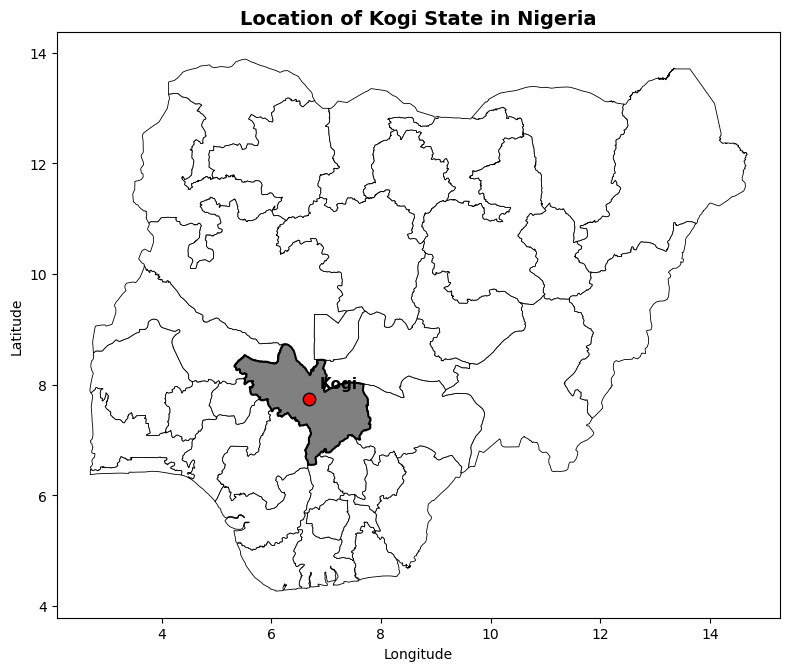

In [36]:
fig, ax = plt.subplots(figsize=(8, 8))

# Plot all Nigerian states
nigeria.plot(
    ax=ax,
    facecolor="white",
    edgecolor="black",
    linewidth=0.6
)

# Highlight Kogi State
kogi.plot(
    ax=ax,
    facecolor="gray",
    edgecolor="black",
    linewidth=1.5
)

# Mark Kogi's approximate center
kogi_center = kogi.geometry.centroid.iloc[0]

ax.scatter(
    kogi_center.x,
    kogi_center.y,
    s=80,
    color="red",
    edgecolor="black",
    zorder=5
)

# Label Kogi
ax.annotate(
    "Kogi",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Location of Kogi State in Nigeria",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [37]:
kogi.geometry.centroid

C:\Users\Okafor Chukwuka .A\AppData\Local\Temp\ipykernel_27320\2740420091.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kogi.geometry.centroid


13    POINT (6.68606 7.73597)
dtype: geometry

In [38]:
# Re-project Kogi to a metric coordinate system
kogi_projected = kogi.to_crs("EPSG:32632")

# Calculate the centroid correctly
kogi_center_projected = kogi_projected.geometry.centroid.iloc[0]

# Convert centroid back to latitude/longitude
kogi_center = gpd.GeoSeries(
    [kogi_center_projected],
    crs="EPSG:32632"
).to_crs("EPSG:4326").iloc[0]

print("Kogi centroid:")
print("Longitude:", kogi_center.x)
print("Latitude:", kogi_center.y)

Kogi centroid:
Longitude: 6.686192969937174
Latitude: 7.736218809430858


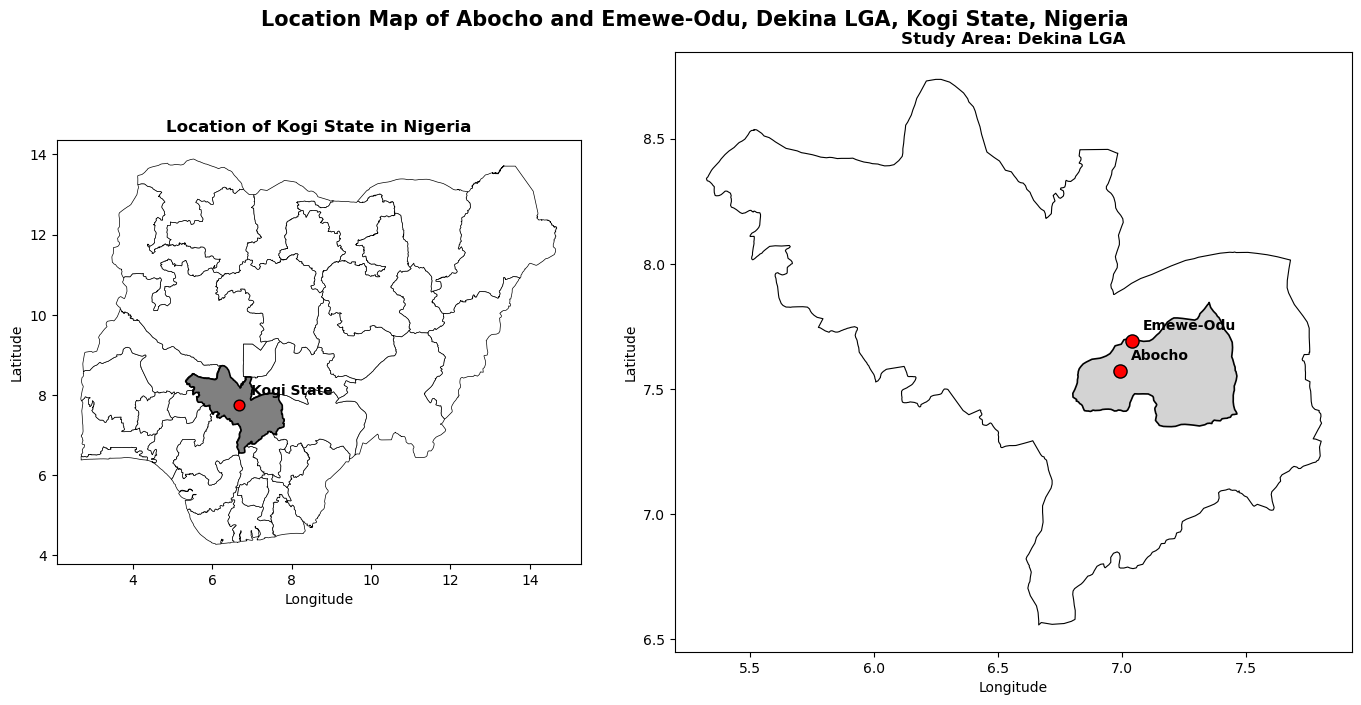

In [39]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7),
    gridspec_kw={"width_ratios": [1, 1.4]}
)

# =========================
# PANEL 1 — NIGERIA
# =========================

nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

kogi.plot(
    ax=axes[0],
    facecolor="gray",
    edgecolor="black",
    linewidth=1.2
)

axes[0].scatter(
    kogi_center.x,
    kogi_center.y,
    s=60,
    color="red",
    edgecolor="black",
    zorder=5
)

axes[0].annotate(
    "Kogi State",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Location of Kogi State in Nigeria",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")


# =========================
# PANEL 2 — DEKINA
# =========================

kogi.plot(
    ax=axes[1],
    facecolor="white",
    edgecolor="black",
    linewidth=0.8
)

dekina.plot(
    ax=axes[1],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.2
)

locations.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=90,
    zorder=5
)

# Add labels
for x, y, label in zip(
    locations.geometry.x,
    locations.geometry.y,
    locations["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Study Area: Dekina LGA",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")


# =========================
# FINAL LAYOUT
# =========================

plt.suptitle(
    "Location Map of Abocho and Emewe-Odu, Dekina LGA, Kogi State, Nigeria",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [40]:
def add_north_arrow(ax, x=0.92, y=0.88, size=0.08):
    ax.annotate(
        "N",
        xy=(x, y),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold"
    )

    ax.annotate(
        "",
        xy=(x, y - size),
        xytext=(x, y - size - 0.08),
        xycoords="axes fraction",
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2
        )
    )

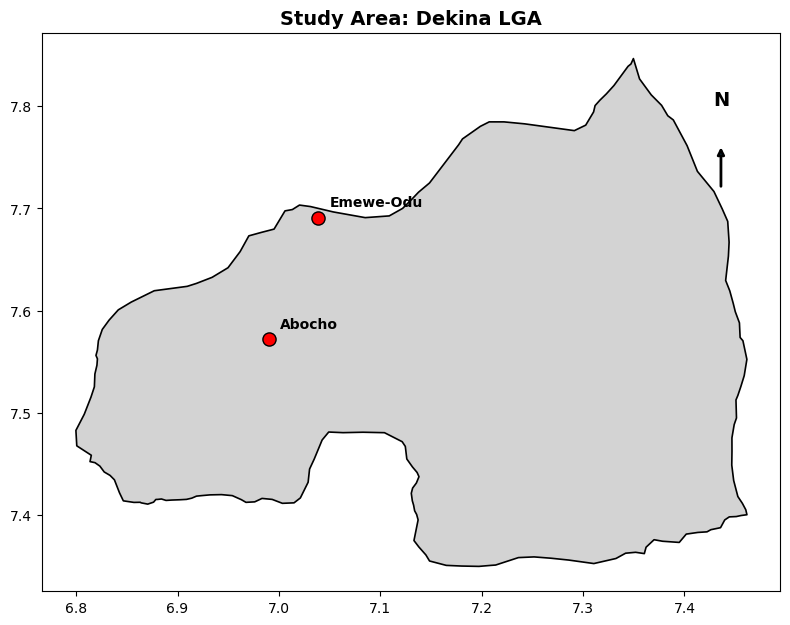

In [41]:
fig, ax = plt.subplots(figsize=(8, 8))

dekina.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.2
)

locations.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=90
)

for x, y, label in zip(
    locations.geometry.x,
    locations.geometry.y,
    locations["Location"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

add_north_arrow(ax)

ax.set_title(
    "Study Area: Dekina LGA",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [42]:
dekina_utm = dekina.to_crs("EPSG:32632")

print(dekina_utm.crs)

EPSG:32632


In [43]:
bounds = dekina_utm.total_bounds

width_km = (bounds[2] - bounds[0]) / 1000
height_km = (bounds[3] - bounds[1]) / 1000

print("Width:", round(width_km, 2), "km")
print("Height:", round(height_km, 2), "km")

Width: 73.08 km
Height: 54.84 km


In [44]:
from matplotlib.patches import Rectangle

def add_scale_bar(ax, length=20, location=(0.08, 0.06), linewidth=5):
    """
    Add a scale bar to a map.

    length: scale bar length in kilometres
    location: position in axes coordinates
    """

    # Get current map limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Convert location from axes fraction to map coordinates
    x = xlim[0] + location[0] * (xlim[1] - xlim[0])
    y = ylim[0] + location[1] * (ylim[1] - ylim[0])

    # Convert kilometres to metres
    length_m = length * 1000

    # Draw scale bar
    ax.plot(
        [x, x + length_m],
        [y, y],
        linewidth=linewidth,
        solid_capstyle="butt"
    )

    # Add end markers
    ax.plot(
        [x, x],
        [y - 500, y + 500],
        linewidth=1.5
    )

    ax.plot(
        [x + length_m, x + length_m],
        [y - 500, y + 500],
        linewidth=1.5
    )

    # Add labels
    ax.text(
        x,
        y + 1500,
        "0",
        ha="center",
        fontsize=10
    )

    ax.text(
        x + length_m,
        y + 1500,
        f"{length} km",
        ha="center",
        fontsize=10
    )

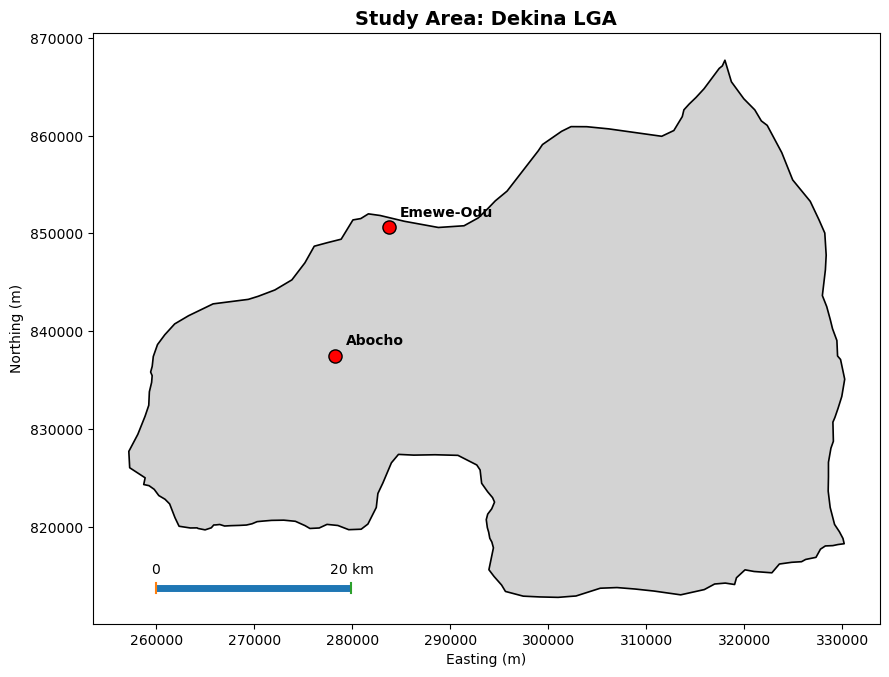

In [45]:
fig, ax = plt.subplots(figsize=(9, 7))

dekina_utm.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.2
)

# Convert our locations to UTM
locations_utm = locations.to_crs("EPSG:32632")

locations_utm.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=90,
    zorder=5
)

# Labels
for x, y, label in zip(
    locations_utm.geometry.x,
    locations_utm.geometry.y,
    locations_utm["Location"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# Add scale bar
add_scale_bar(ax, length=20)

ax.set_title(
    "Study Area: Dekina LGA",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

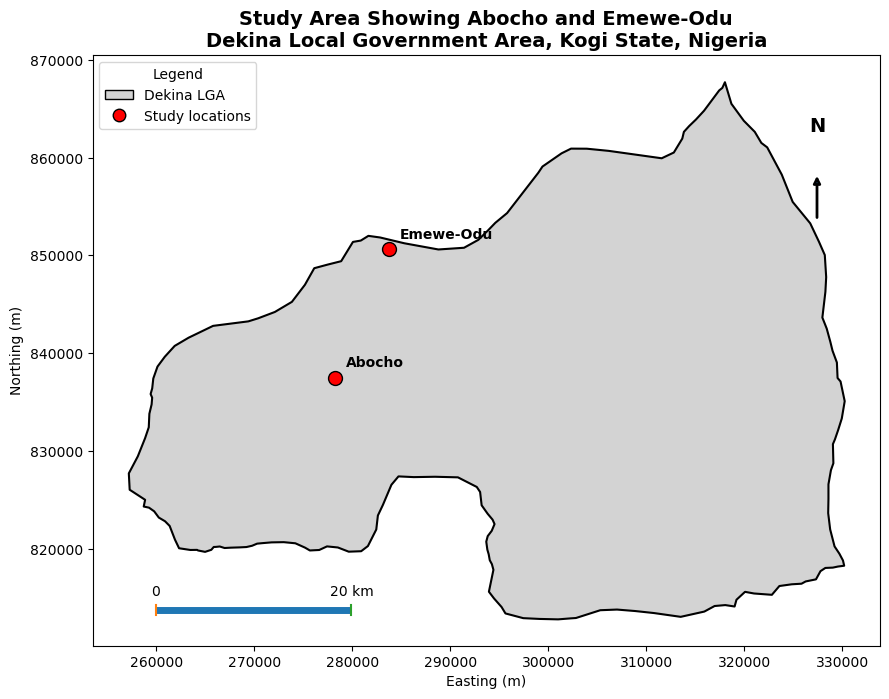

In [46]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 7))

# -------------------------
# Dekina LGA
# -------------------------
dekina_utm.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# -------------------------
# Study locations
# -------------------------
locations_utm.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=100,
    zorder=5
)

# -------------------------
# Labels
# -------------------------
for x, y, label in zip(
    locations_utm.geometry.x,
    locations_utm.geometry.y,
    locations_utm["Location"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# -------------------------
# North Arrow
# -------------------------
add_north_arrow(ax)

# -------------------------
# Scale Bar
# -------------------------
add_scale_bar(ax, length=20)

# -------------------------
# Legend
# -------------------------
legend_elements = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="lightgray",
        edgecolor="black",
        label="Dekina LGA"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=9,
        label="Study locations"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper left",
    title="Legend",
    frameon=True
)

# -------------------------
# Title
# -------------------------
ax.set_title(
    "Study Area Showing Abocho and Emewe-Odu\n"
    "Dekina Local Government Area, Kogi State, Nigeria",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

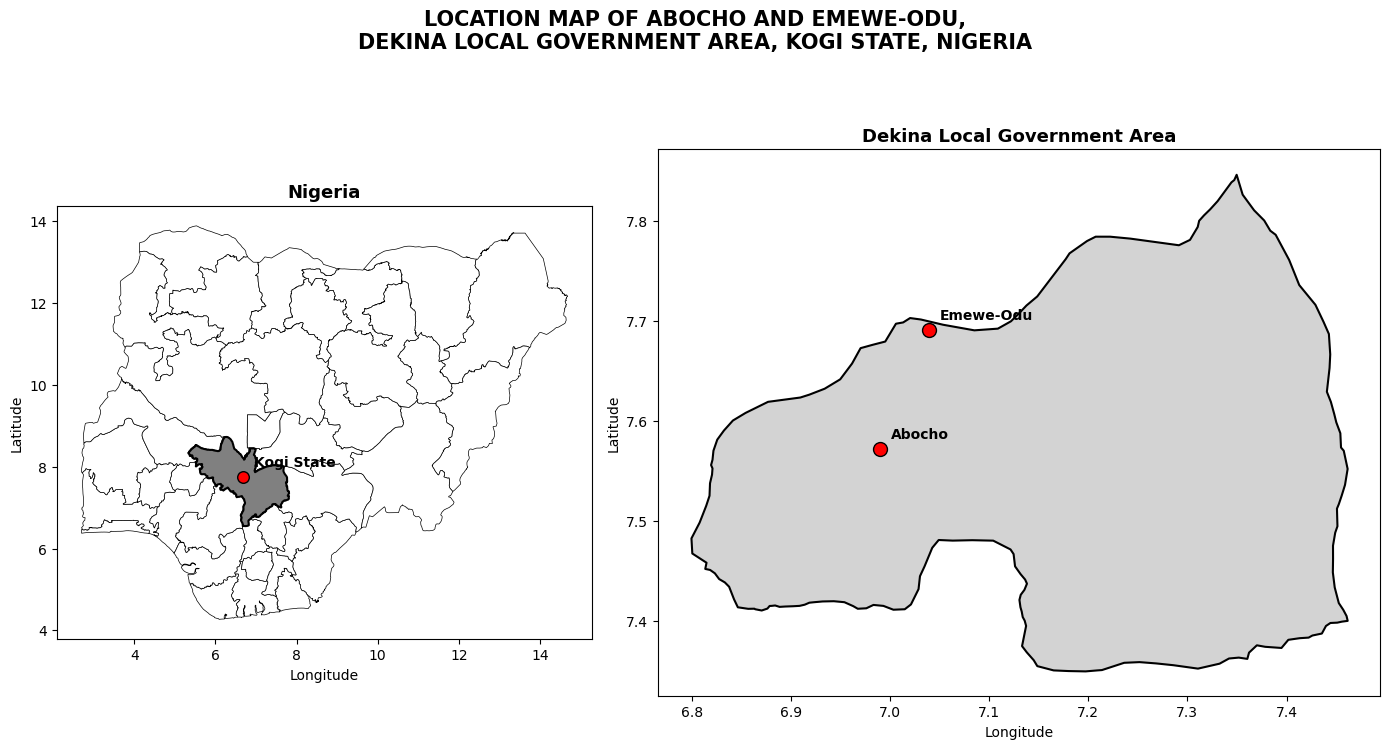

In [47]:
# Convert Dekina and locations back to geographic coordinates
dekina_geo = dekina.to_crs("EPSG:4326")
locations_geo = locations.to_crs("EPSG:4326")

# Create figure
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"width_ratios": [1, 1.35]}
)

# ==========================================
# PANEL 1 — NIGERIA / KOGI
# ==========================================

nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

kogi.plot(
    ax=axes[0],
    facecolor="gray",
    edgecolor="black",
    linewidth=1.5
)

axes[0].scatter(
    kogi_center.x,
    kogi_center.y,
    s=70,
    color="red",
    edgecolor="black",
    zorder=5
)

axes[0].annotate(
    "Kogi State",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Nigeria",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")


# ==========================================
# PANEL 2 — DEKINA
# ==========================================

dekina_geo.plot(
    ax=axes[1],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

locations_geo.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=100,
    zorder=5
)

# Labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Dekina Local Government Area",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")


# ==========================================
# MAIN TITLE
# ==========================================

fig.suptitle(
    "LOCATION MAP OF ABOCHO AND EMEWE-ODU,\n"
    "DEKINA LOCAL GOVERNMENT AREA, KOGI STATE, NIGERIA",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

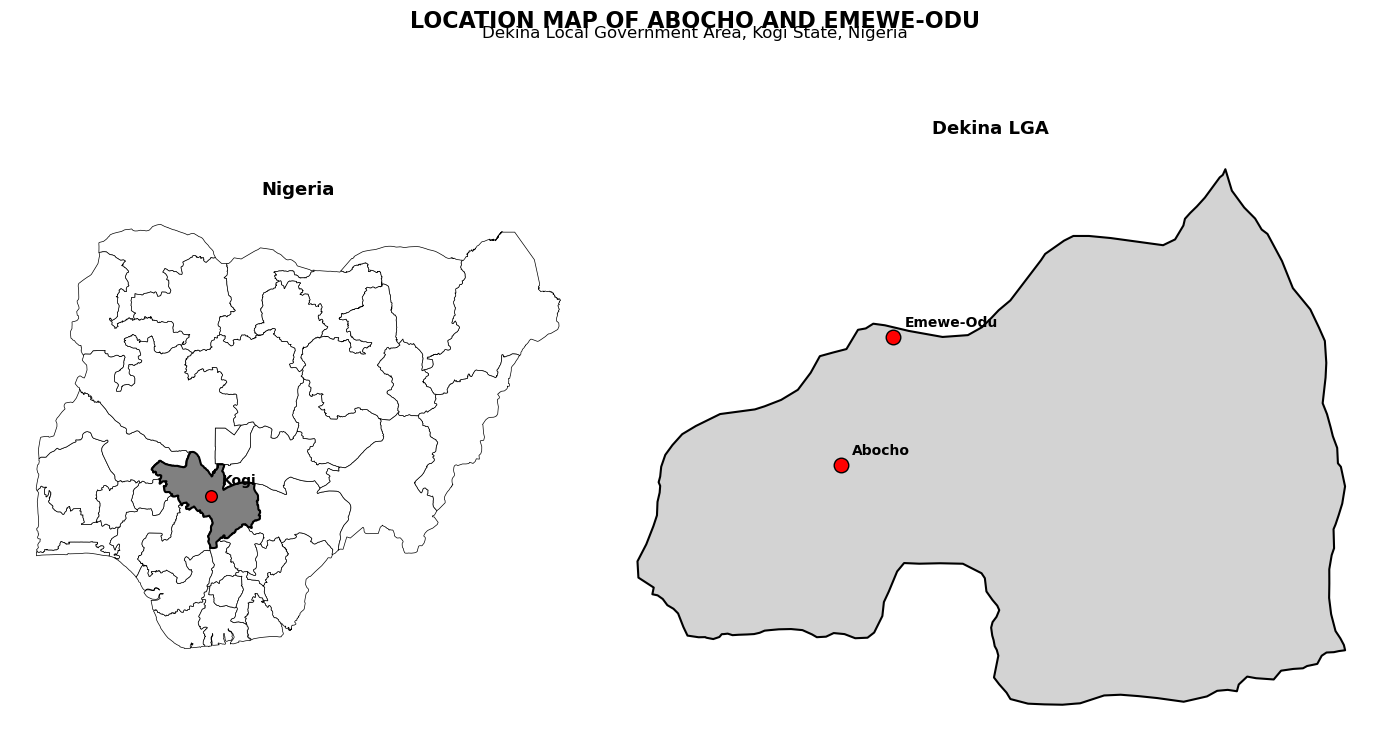

In [48]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"width_ratios": [1, 1.35]}
)

# ==========================================
# PANEL 1 — NIGERIA
# ==========================================

nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

kogi.plot(
    ax=axes[0],
    facecolor="gray",
    edgecolor="black",
    linewidth=1.5
)

axes[0].scatter(
    kogi_center.x,
    kogi_center.y,
    s=70,
    color="red",
    edgecolor="black",
    zorder=5
)

axes[0].annotate(
    "Kogi",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Nigeria",
    fontsize=13,
    fontweight="bold"
)

# Remove axes
axes[0].set_axis_off()


# ==========================================
# PANEL 2 — DEKINA
# ==========================================

dekina_geo.plot(
    ax=axes[1],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

locations_geo.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=110,
    zorder=5
)

# Location labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Dekina LGA",
    fontsize=13,
    fontweight="bold"
)

# Remove axes
axes[1].set_axis_off()


# ==========================================
# MAIN TITLE
# ==========================================

fig.suptitle(
    "LOCATION MAP OF ABOCHO AND EMEWE-ODU",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.925,
    "Dekina Local Government Area, Kogi State, Nigeria",
    ha="center",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

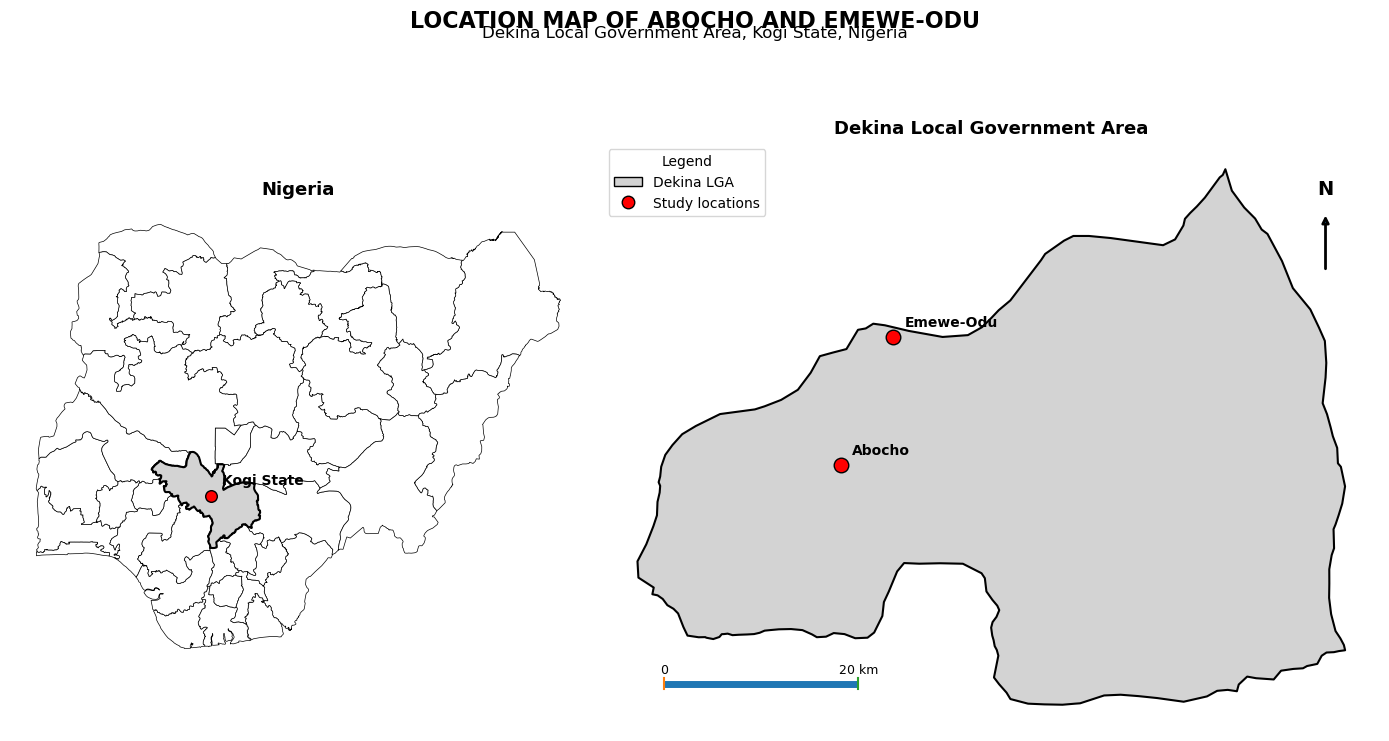

In [49]:
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"width_ratios": [1, 1.35]}
)

# ==================================================
# PANEL 1 — NIGERIA
# ==================================================

nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

kogi.plot(
    ax=axes[0],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Kogi location marker
axes[0].scatter(
    kogi_center.x,
    kogi_center.y,
    s=70,
    color="red",
    edgecolor="black",
    zorder=5
)

axes[0].annotate(
    "Kogi State",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Nigeria",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_axis_off()


# ==================================================
# PANEL 2 — DEKINA
# ==================================================

dekina_geo.plot(
    ax=axes[1],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

locations_geo.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=110,
    zorder=5
)

# Location labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


# ==================================================
# NORTH ARROW
# ==================================================

axes[1].annotate(
    "N",
    xy=(0.93, 0.92),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

axes[1].annotate(
    "",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.78),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)


# ==================================================
# LEGEND
# ==================================================

legend_elements = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="lightgray",
        edgecolor="black",
        label="Dekina LGA"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=9,
        label="Study locations"
    )
]

axes[1].legend(
    handles=legend_elements,
    loc="upper left",
    title="Legend",
    frameon=True
)

axes[1].set_title(
    "Dekina Local Government Area",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_axis_off()


# ==================================================
# MAIN TITLE
# ==================================================

fig.suptitle(
    "LOCATION MAP OF ABOCHO AND EMEWE-ODU",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.925,
    "Dekina Local Government Area, Kogi State, Nigeria",
    ha="center",
    fontsize=12
)


# ==================================================
# SCALE BAR
# ==================================================

# Get current limits of the Dekina map
xlim = axes[1].get_xlim()
ylim = axes[1].get_ylim()

# Position scale bar near bottom-left
x_start = xlim[0] + 0.08 * (xlim[1] - xlim[0])
y_start = ylim[0] + 0.08 * (ylim[1] - ylim[0])

# Approximate 20 km in longitude at this latitude
scale_length = 20 / 110

axes[1].plot(
    [x_start, x_start + scale_length],
    [y_start, y_start],
    linewidth=5,
    solid_capstyle="butt"
)

axes[1].plot(
    [x_start, x_start],
    [y_start - 0.005, y_start + 0.005],
    linewidth=1.5
)

axes[1].plot(
    [x_start + scale_length, x_start + scale_length],
    [y_start - 0.005, y_start + 0.005],
    linewidth=1.5
)

axes[1].text(
    x_start,
    y_start + 0.01,
    "0",
    ha="center",
    fontsize=9
)

axes[1].text(
    x_start + scale_length,
    y_start + 0.01,
    "20 km",
    ha="center",
    fontsize=9
)


# ==================================================
# FINAL LAYOUT
# ==================================================

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

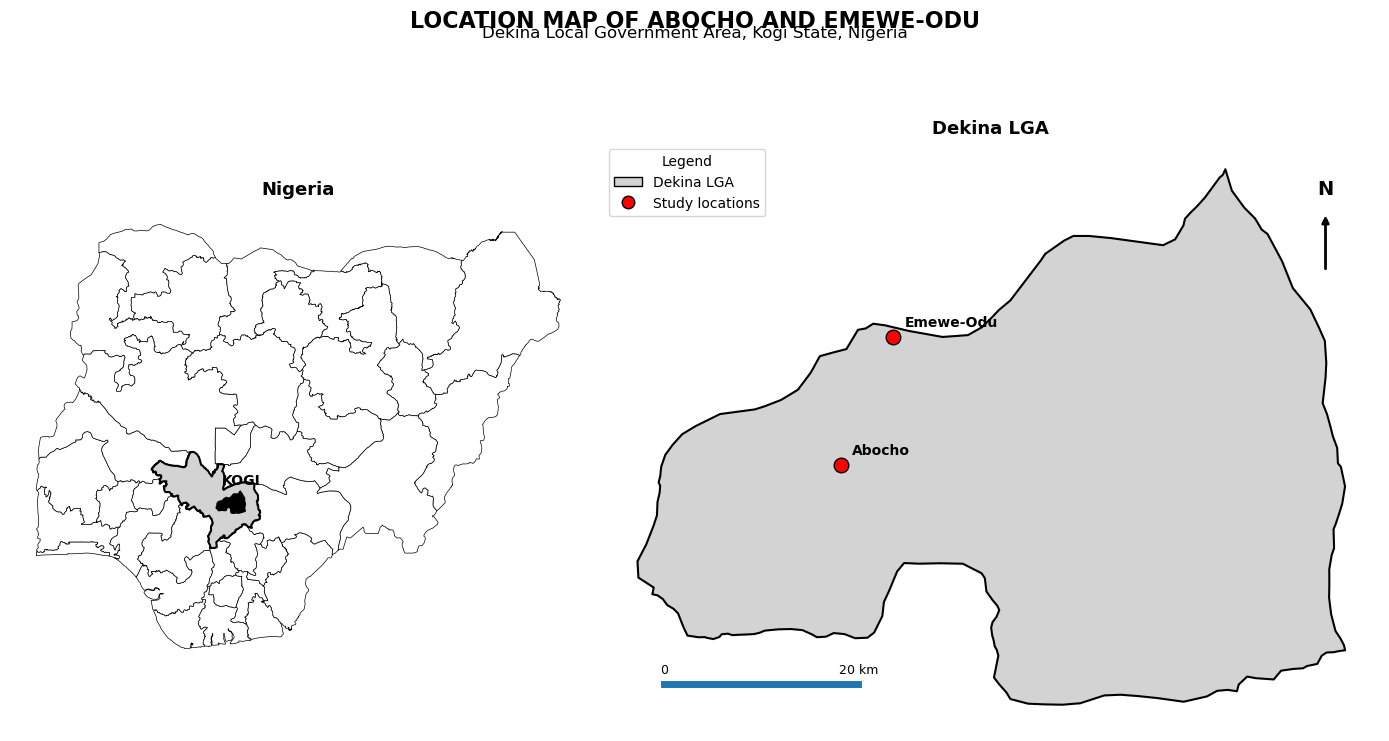

In [50]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 8),
    gridspec_kw={"width_ratios": [1, 1.35]}
)

# ==================================================
# PANEL 1 — NIGERIA
# ==================================================

# All states
nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

# Kogi State
kogi.plot(
    ax=axes[0],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5,
    zorder=2
)

# Dekina inside Kogi
dekina_geo.plot(
    ax=axes[0],
    facecolor="black",
    edgecolor="black",
    linewidth=1.2,
    zorder=3
)

# Kogi label
axes[0].annotate(
    "KOGI",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Nigeria",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_axis_off()


# ==================================================
# PANEL 2 — DEKINA
# ==================================================

dekina_geo.plot(
    ax=axes[1],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Study locations
locations_geo.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=110,
    zorder=5
)

# Labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


# ==================================================
# NORTH ARROW
# ==================================================

axes[1].annotate(
    "N",
    xy=(0.93, 0.92),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

axes[1].annotate(
    "",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.78),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)


# ==================================================
# LEGEND
# ==================================================

legend_elements = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="lightgray",
        edgecolor="black",
        label="Dekina LGA"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=9,
        label="Study locations"
    )
]

axes[1].legend(
    handles=legend_elements,
    loc="upper left",
    title="Legend",
    frameon=True
)

axes[1].set_title(
    "Dekina LGA",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_axis_off()


# ==================================================
# SCALE BAR
# ==================================================

xlim = axes[1].get_xlim()
ylim = axes[1].get_ylim()

x_start = xlim[0] + 0.08 * (xlim[1] - xlim[0])
y_start = ylim[0] + 0.08 * (ylim[1] - ylim[0])

scale_length = 20 / 110

axes[1].plot(
    [x_start, x_start + scale_length],
    [y_start, y_start],
    linewidth=5
)

axes[1].text(
    x_start,
    y_start + 0.01,
    "0",
    ha="center",
    fontsize=9
)

axes[1].text(
    x_start + scale_length,
    y_start + 0.01,
    "20 km",
    ha="center",
    fontsize=9
)


# ==================================================
# MAIN TITLE
# ==================================================

fig.suptitle(
    "LOCATION MAP OF ABOCHO AND EMEWE-ODU",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

fig.text(
    0.5,
    0.925,
    "Dekina Local Government Area, Kogi State, Nigeria",
    ha="center",
    fontsize=12
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

In [51]:
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

def add_accurate_scale_bar(ax, length_km=20):
    
    # Get the map limits in longitude/latitude
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Starting position
    x_start = xlim[0] + 0.08 * (xlim[1] - xlim[0])
    y_start = ylim[0] + 0.07 * (ylim[1] - ylim[0])
    
    # Latitude at scale-bar position
    latitude = y_start
    
    # Approximate longitude distance represented by 20 km
    # using Earth's latitude-dependent longitude length
    import math
    
    km_per_degree_lon = 111.32 * math.cos(math.radians(latitude))
    degree_length = length_km / km_per_degree_lon
    
    # Draw scale bar
    ax.plot(
        [x_start, x_start + degree_length],
        [y_start, y_start],
        linewidth=5,
        solid_capstyle="butt",
        zorder=10
    )
    
    # End ticks
    tick_height = 0.008 * (ylim[1] - ylim[0])
    
    ax.plot(
        [x_start, x_start],
        [y_start - tick_height, y_start + tick_height],
        linewidth=1.5,
        zorder=10
    )
    
    ax.plot(
        [x_start + degree_length, x_start + degree_length],
        [y_start - tick_height, y_start + tick_height],
        linewidth=1.5,
        zorder=10
    )
    
    # Labels
    ax.text(
        x_start,
        y_start + 0.015 * (ylim[1] - ylim[0]),
        "0",
        ha="center",
        fontsize=9
    )
    
    ax.text(
        x_start + degree_length,
        y_start + 0.015 * (ylim[1] - ylim[0]),
        f"{length_km} km",
        ha="center",
        fontsize=9
    )

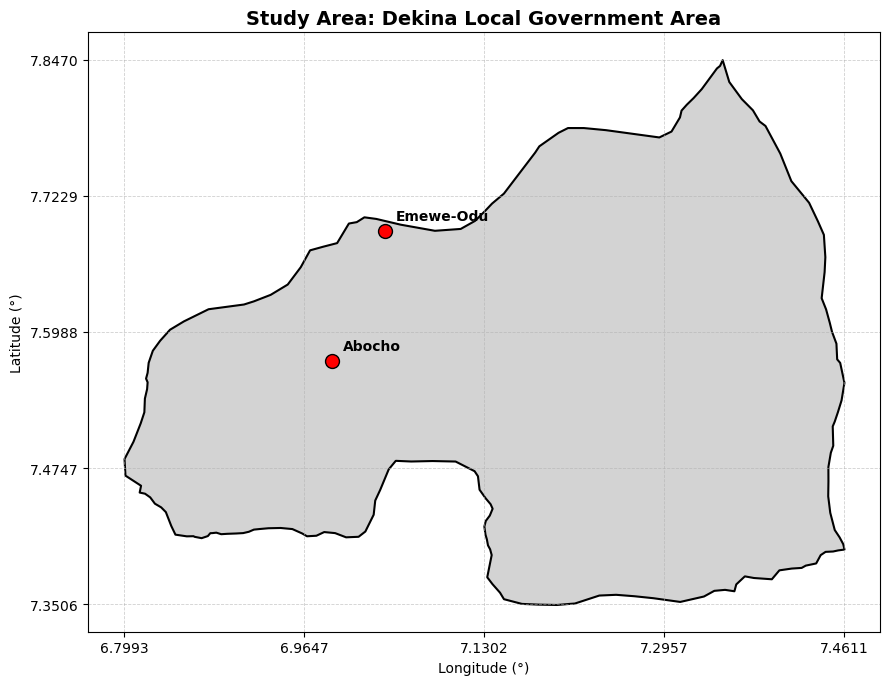

In [52]:
import numpy as np

fig, ax = plt.subplots(figsize=(9, 7))

# Plot Dekina
dekina_geo.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Plot locations
locations_geo.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    markersize=100,
    zorder=5
)

# Add labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

# Get map limits
xmin, ymin, xmax, ymax = dekina_geo.total_bounds

# Create longitude and latitude gridlines
longitude_lines = np.linspace(xmin, xmax, 5)
latitude_lines = np.linspace(ymin, ymax, 5)

ax.set_xticks(longitude_lines)
ax.set_yticks(latitude_lines)

# Format gridlines
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.6
)

# Axis labels
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

# Title
ax.set_title(
    "Study Area: Dekina Local Government Area",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

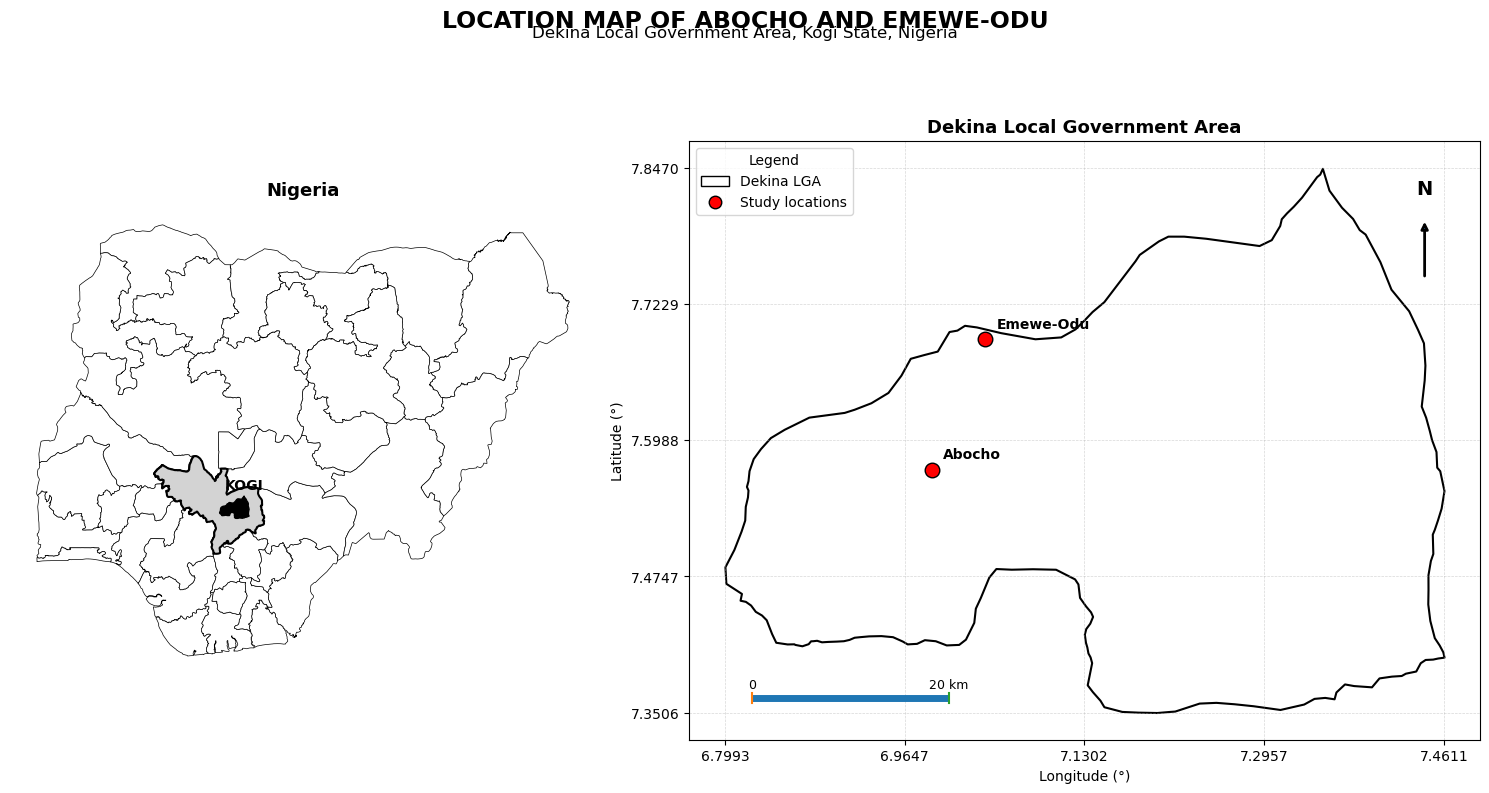

In [53]:
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 8),
    gridspec_kw={"width_ratios": [1, 1.35]}
)

# ============================================================
# PANEL 1 — NIGERIA / KOGI / DEKINA
# ============================================================

nigeria.plot(
    ax=axes[0],
    facecolor="white",
    edgecolor="black",
    linewidth=0.5
)

# Kogi State
kogi.plot(
    ax=axes[0],
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5,
    zorder=2
)

# Dekina inside Kogi
dekina_geo.plot(
    ax=axes[0],
    facecolor="black",
    edgecolor="black",
    linewidth=1.0,
    zorder=3
)

# Kogi label
axes[0].annotate(
    "KOGI",
    xy=(kogi_center.x, kogi_center.y),
    xytext=(8, 8),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

axes[0].set_title(
    "Nigeria",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_axis_off()


# ============================================================
# PANEL 2 — DEKINA STUDY AREA
# ============================================================

dekina_geo.plot(
    ax=axes[1],
    facecolor="white",
    edgecolor="black",
    linewidth=1.5,
    zorder=1
)

# Study locations
locations_geo.plot(
    ax=axes[1],
    color="red",
    edgecolor="black",
    markersize=110,
    zorder=5
)

# Location labels
for x, y, label in zip(
    locations_geo.geometry.x,
    locations_geo.geometry.y,
    locations_geo["Location"]
):
    axes[1].annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )


# ============================================================
# COORDINATE GRID
# ============================================================

xmin, ymin, xmax, ymax = dekina_geo.total_bounds

longitude_lines = np.linspace(xmin, xmax, 5)
latitude_lines = np.linspace(ymin, ymax, 5)

axes[1].set_xticks(longitude_lines)
axes[1].set_yticks(latitude_lines)

axes[1].grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.5
)

axes[1].set_xlabel("Longitude (°)")
axes[1].set_ylabel("Latitude (°)")


# ============================================================
# NORTH ARROW
# ============================================================

axes[1].annotate(
    "N",
    xy=(0.93, 0.92),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

axes[1].annotate(
    "",
    xy=(0.93, 0.87),
    xytext=(0.93, 0.77),
    xycoords="axes fraction",
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=2
    )
)


# ============================================================
# ACCURATE 20 KM SCALE BAR
# ============================================================

xlim = axes[1].get_xlim()
ylim = axes[1].get_ylim()

x_start = xlim[0] + 0.08 * (xlim[1] - xlim[0])
y_start = ylim[0] + 0.07 * (ylim[1] - ylim[0])

latitude = y_start

km_per_degree_lon = (
    111.32 * math.cos(math.radians(latitude))
)

scale_length = 20 / km_per_degree_lon

axes[1].plot(
    [x_start, x_start + scale_length],
    [y_start, y_start],
    linewidth=5,
    solid_capstyle="butt",
    zorder=10
)

tick_height = 0.008 * (ylim[1] - ylim[0])

axes[1].plot(
    [x_start, x_start],
    [y_start - tick_height, y_start + tick_height],
    linewidth=1.5,
    zorder=10
)

axes[1].plot(
    [
        x_start + scale_length,
        x_start + scale_length
    ],
    [
        y_start - tick_height,
        y_start + tick_height
    ],
    linewidth=1.5,
    zorder=10
)

axes[1].text(
    x_start,
    y_start + 0.015 * (ylim[1] - ylim[0]),
    "0",
    ha="center",
    fontsize=9
)

axes[1].text(
    x_start + scale_length,
    y_start + 0.015 * (ylim[1] - ylim[0]),
    "20 km",
    ha="center",
    fontsize=9
)


# ============================================================
# LEGEND
# ============================================================

legend_elements = [
    Rectangle(
        (0, 0),
        1,
        1,
        facecolor="white",
        edgecolor="black",
        label="Dekina LGA"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor="red",
        markeredgecolor="black",
        markersize=9,
        label="Study locations"
    )
]

axes[1].legend(
    handles=legend_elements,
    loc="upper left",
    title="Legend",
    frameon=True
)


# ============================================================
# STUDY AREA TITLE
# ============================================================

axes[1].set_title(
    "Dekina Local Government Area",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(
    "LOCATION MAP OF ABOCHO AND EMEWE-ODU",
    fontsize=17,
    fontweight="bold",
    y=0.97
)

fig.text(
    0.5,
    0.935,
    "Dekina Local Government Area, Kogi State, Nigeria",
    ha="center",
    fontsize=12
)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.91]
)

plt.show()

In [54]:
fig.text(
    0.5,
    0.02,
    "Source: geoBoundaries (GRID3 Nigeria Administrative Boundaries, 2022); "
    "coordinates obtained from geographic location data.",
    ha="center",
    fontsize=8
)

Text(0.5, 0.02, 'Source: geoBoundaries (GRID3 Nigeria Administrative Boundaries, 2022); coordinates obtained from geographic location data.')

In [55]:
plt.tight_layout(
    rect=[0, 0.04, 1, 0.91]
)

fig.text(
    0.5,
    0.02,
    "Source: geoBoundaries (GRID3 Nigeria Administrative Boundaries, 2022); "
    "coordinates obtained from geographic location data.",
    ha="center",
    fontsize=8
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [56]:
fig.savefig(
    "Abocho_Emewe_Odu_Location_Map.png",
    dpi=600,
    bbox_inches="tight"
)

In [57]:
fig.savefig(
    "Abocho_Emewe_Odu_Location_Map.pdf",
    bbox_inches="tight"
)